In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV, learning_curve, ShuffleSplit
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

random_state = 42

In [3]:
data_path = './Data/german.data-numeric'
credit = np.genfromtxt(data_path)
print(credit)

[[ 1.  6.  4. ...  0.  1.  1.]
 [ 2. 48.  2. ...  0.  1.  2.]
 [ 4. 12.  4. ...  1.  0.  1.]
 ...
 [ 4. 12.  2. ...  0.  1.  1.]
 [ 1. 45.  2. ...  0.  1.  2.]
 [ 2. 45.  4. ...  0.  1.  1.]]


In [4]:
X, y = credit[:, :-1], credit[:, -1]
print(X.shape, y.shape)

(1000, 24) (1000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = random_state)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(800, 24) (800,)
(200, 24) (200,)


In [6]:
DT = DecisionTreeClassifier(random_state=random_state)
DT.fit(X_train, y_train)
y_pred_dt = DT.predict(X_test)
print("Decision Tree:")
print(classification_report(y_test, y_pred_dt))
RF = RandomForestClassifier(random_state=random_state)
RF.fit(X_train, y_train)
y_pred_rf = RF.predict(X_test)
print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Decision Tree:
              precision    recall  f1-score   support

         1.0       0.76      0.77      0.76       141
         2.0       0.43      0.42      0.43        59

    accuracy                           0.67       200
   macro avg       0.60      0.59      0.60       200
weighted avg       0.66      0.67      0.66       200

Random Forest:
              precision    recall  f1-score   support

         1.0       0.82      0.94      0.88       141
         2.0       0.78      0.49      0.60        59

    accuracy                           0.81       200
   macro avg       0.80      0.72      0.74       200
weighted avg       0.81      0.81      0.80       200



In [7]:
print("-DT accuracy:", accuracy_score(y_test, y_pred_dt))
print("-RF accuracy:", accuracy_score(y_test, y_pred_rf))

-DT accuracy: 0.665
-RF accuracy: 0.81


In [8]:
print("-DT roc_auc:", roc_auc_score(y_test, y_pred_dt))
print("-RF roc_auc:", roc_auc_score(y_test, y_pred_rf))

-DT roc_auc: 0.5948431301839163
-RF roc_auc: 0.7173939175381656


In [9]:
print("-DT confusion matrix:\n", confusion_matrix(y_test, y_pred_dt))
print("-RF confusion matrix:\n", confusion_matrix(y_test, y_pred_rf))

-DT confusion matrix:
 [[108  33]
 [ 34  25]]
-RF confusion matrix:
 [[133   8]
 [ 30  29]]


In [10]:
def grid_search(algorithm, n_jobs, dict_params):
    if algorithm == 'Decision Tree':
        model = DecisionTreeClassifier(random_state=random_state)
    elif algorithm == 'Random Forest':
        model = RandomForestClassifier(random_state=random_state)
    
    classifier = GridSearchCV(model, dict_params, cv=5, n_jobs=n_jobs, scoring = 'f1')
    classifier.fit(X_train, y_train)
    print(f"Best parameters for {algorithm}: {classifier.best_params_}")
    print(f"Best F1 score for {algorithm}: {classifier.best_score_:.4f}")
    return classifier.best_estimator_

def evaluate(model):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    print("Train classification report:")
    print(classification_report(y_train, y_train_pred))
    print("Train roc_auc:", roc_auc_score(y_train, y_train_pred))
    print("Train confusion matrix:\n", confusion_matrix(y_train, y_train_pred))
    print("-" * 50)
    print("Test classification report:")
    print(classification_report(y_test, y_test_pred))
    print("Test roc_auc:", roc_auc_score(y_test, y_test_pred))
    print("Test confusion matrix:\n", confusion_matrix(y_test, y_test_pred))


In [11]:
def plot_learning_curve(estimator, title, X, y, cv=None, n_jobs=None):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    plt.figure()
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    plt.legend(loc="best")
    return plt

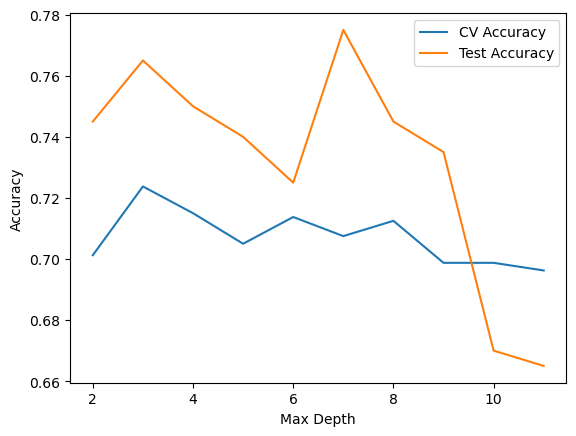

In [12]:
cv_accuracies_by_depth, test_accuracies_by_depth = [], []
max_depths = range(2, 12)
for max_depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    cv_scores = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')
    cv_accuracies_by_depth.append(np.mean(cv_scores))
    dt.fit(X_train, y_train)
    test_accuracies_by_depth.append(accuracy_score(y_test, dt.predict(X_test)))

plt.plot(max_depths, cv_accuracies_by_depth, label='CV Accuracy')
plt.plot(max_depths, test_accuracies_by_depth, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [14]:
dict_param = {
    'max_depth': [2, 3, 5, 7, 10, 20],
    'min_samples_leaf': [5, 10, 20, 50, 100],
    'criterion': ["gini", "entropy"]
}
best_tree = grid_search('Decision Tree', n_jobs=-1, dict_params=dict_param)

Best parameters for Decision Tree: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 20}
Best F1 score for Decision Tree: 0.8284


Train classification report:
              precision    recall  f1-score   support

         1.0       0.79      0.91      0.85       559
         2.0       0.68      0.45      0.54       241

    accuracy                           0.77       800
   macro avg       0.74      0.68      0.70       800
weighted avg       0.76      0.77      0.76       800

Train roc_auc: 0.680523905314024
Train confusion matrix:
 [[508  51]
 [132 109]]
--------------------------------------------------
Test classification report:
              precision    recall  f1-score   support

         1.0       0.81      0.91      0.85       141
         2.0       0.68      0.47      0.56        59

    accuracy                           0.78       200
   macro avg       0.74      0.69      0.71       200
weighted avg       0.77      0.78      0.77       200

Test roc_auc: 0.6911888448130785
Test confusion matrix:
 [[128  13]
 [ 31  28]]


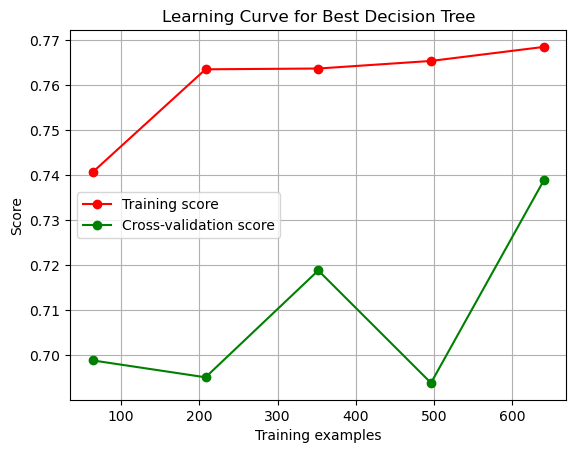

In [15]:
best_tree.fit(X_train, y_train)
evaluate(best_tree)
plot_learning_curve(best_tree, "Learning Curve for Best Decision Tree", X_train, y_train, cv=5, n_jobs=-1).show()

Top 10 important features:
1. Feature 0 (0.4045)
2. Feature 1 (0.1707)
3. Feature 2 (0.1426)
4. Feature 4 (0.0712)
5. Feature 9 (0.0543)
6. Feature 10 (0.0540)
7. Feature 16 (0.0401)
8. Feature 8 (0.0381)
9. Feature 7 (0.0151)
10. Feature 3 (0.0095)


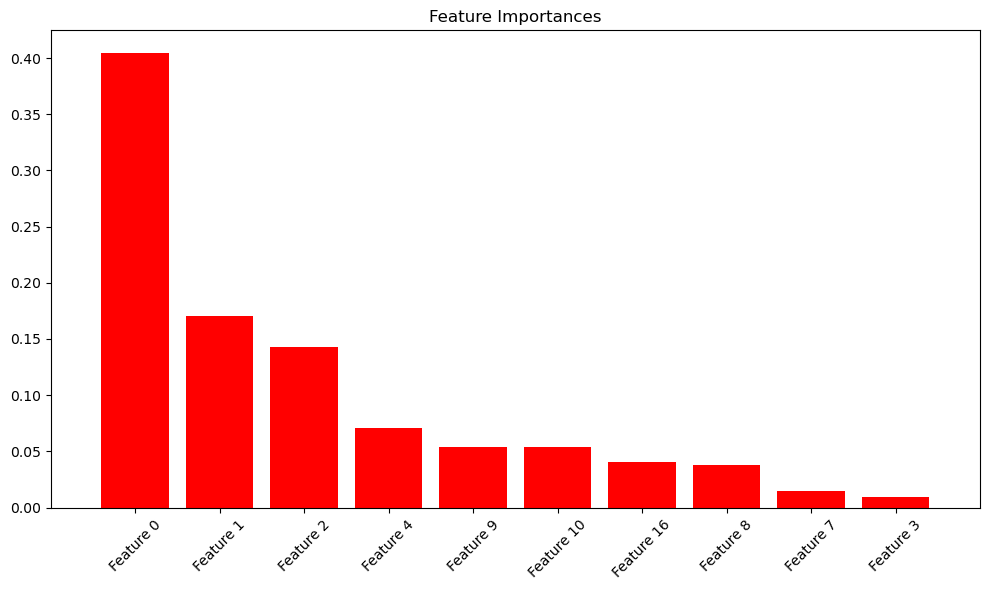

In [16]:
importances = best_tree.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
print("Top 10 important features:")
for i in range(10):
    print(f"{i + 1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

indices = indices[:10]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(len(indices)), importances[indices], color="r", align="center")
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45)
plt.xlim([-1, len(indices)])
plt.tight_layout()
plt.show()

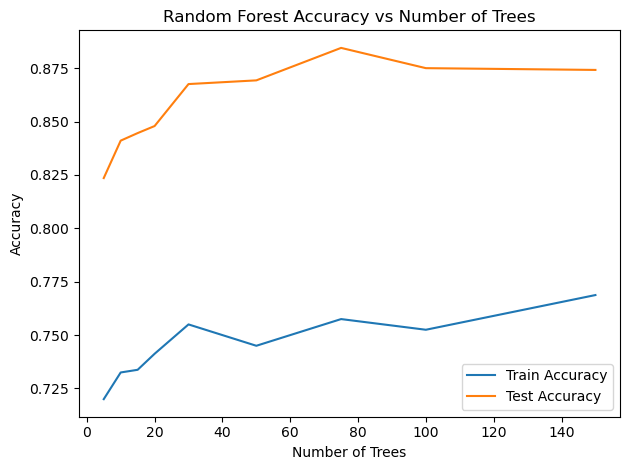

In [18]:
num_trees = [5, 10, 15, 20, 30, 50, 75, 100, 150]

train_acc = []
test_acc = []

for n in num_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=random_state)
    rf.fit(X_train, y_train)
    temp_train_acc = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy').mean()
    train_acc.append(temp_train_acc)
    test_acc.append(f1_score(y_test, rf.predict(X_test)))
plt.plot(num_trees, train_acc, label='Train Accuracy')
plt.plot(num_trees, test_acc, label='Test Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Random Forest Accuracy vs Number of Trees')
plt.tight_layout()
plt.show()

Best parameters for Random Forest: {'max_depth': 11, 'max_features': 6, 'min_samples_leaf': 1, 'n_estimators': 75}
Best F1 score for Random Forest: 0.8417
Train classification report:
              precision    recall  f1-score   support

         1.0       0.98      1.00      0.99       559
         2.0       1.00      0.96      0.98       241

    accuracy                           0.99       800
   macro avg       0.99      0.98      0.99       800
weighted avg       0.99      0.99      0.99       800

Train roc_auc: 0.9813278008298756
Train confusion matrix:
 [[559   0]
 [  9 232]]
--------------------------------------------------
Test classification report:
              precision    recall  f1-score   support

         1.0       0.81      0.91      0.86       141
         2.0       0.71      0.49      0.58        59

    accuracy                           0.79       200
   macro avg       0.76      0.70      0.72       200
weighted avg       0.78      0.79      0.78       200

T

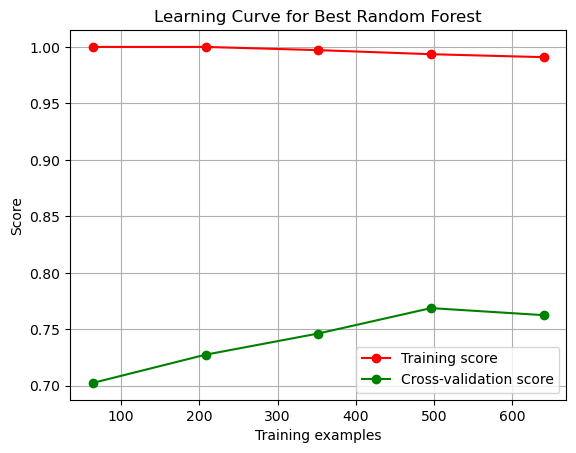

In [20]:
dict_param = {
    'max_depth': [3, 11, 15, 24, 27],
    'min_samples_leaf': [1, 5, 7, 9, 15, 24],
    'max_features': [4, 6, 10, 16],
    'n_estimators': [75]
}
best_rf = grid_search('Random Forest', n_jobs=-1, dict_params=dict_param)
evaluate(best_rf)
plot_learning_curve(best_rf, "Learning Curve for Best Random Forest", X_train, y_train, cv=5, n_jobs=-1).show()

Top 10 important features in Random Forest:
1. Feature 3 (0.1393)
2. Feature 0 (0.1176)
3. Feature 9 (0.1165)
4. Feature 1 (0.1016)
5. Feature 2 (0.0749)
6. Feature 5 (0.0592)
7. Feature 8 (0.0498)
8. Feature 4 (0.0456)
9. Feature 7 (0.0422)
10. Feature 6 (0.0367)


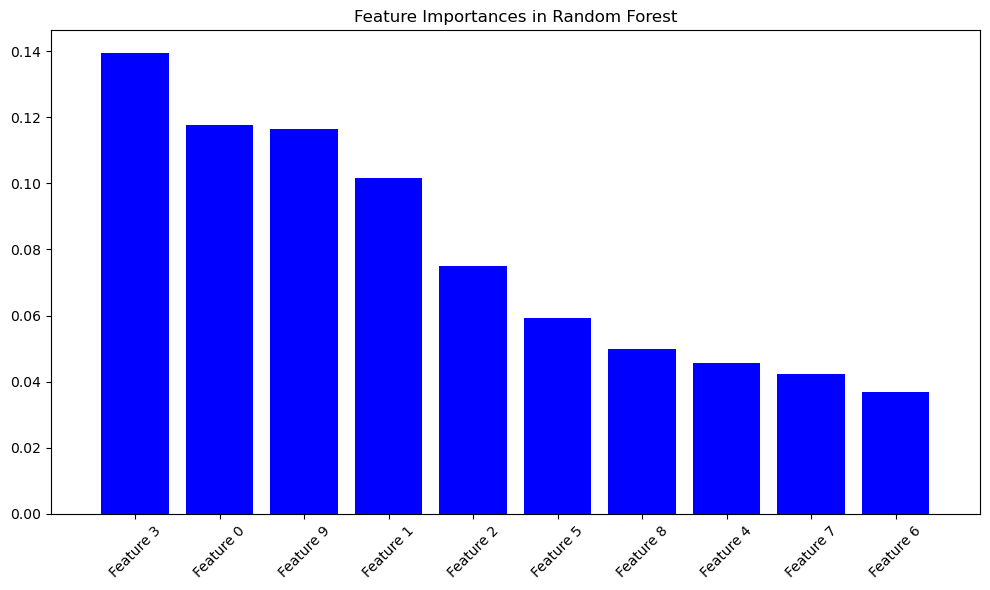

In [21]:
best_rf.fit(X_train, y_train)
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = [f"Feature {i}" for i in range(X.shape[1])]
print("Top 10 important features in Random Forest:")
for i in range(10):
    print(f"{i + 1}. {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")
indices = indices[:10]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances in Random Forest")
plt.bar(range(len(indices)), importances[indices], color="b", align="center")
plt.xticks(range(len(indices)), [feature_names[i] for i in indices], rotation=45)
plt.xlim([-1, len(indices)])
plt.tight_layout()
plt.show()

In [22]:
sfm = SelectFromModel(best_rf, threshold='mean')
sfm.fit(X_train, y_train)
X_train_dropped = sfm.transform(X_train)
X_test_dropped = sfm.transform(X_test)
print("Original number of features:", X_train.shape[1])
print("Number of features after dropping:", X_train_dropped.shape[1])

Original number of features: 24
Number of features after dropping: 9


In [23]:
title = 'Learning with dropped features'
label_curve = {'train': 'train', 'test': 'cv'}
forest_dropped = RandomForestClassifier(**best_rf.get_params())
forest_dropped.fit(X_train_dropped, y_train)
y_dropped_pred = forest_dropped.predict(X_test_dropped)

print("Accuracy: ", accuracy_score(y_test, y_dropped_pred))
print("f1: ", f1_score(y_test, y_dropped_pred))
print("roc_auc: ", roc_auc_score(y_test, y_dropped_pred))



Accuracy:  0.78
f1:  0.8552631578947368
roc_auc:  0.6813318908522659


In [24]:
params = {
    'max_depth': best_rf.get_params()['max_depth'],
    'max_features': best_rf.get_params()['max_features'],
    'min_samples_leaf': best_rf.get_params()['min_samples_leaf'],
    'n_estimators': best_rf.get_params()['n_estimators'],
}
evaluate(best_rf)

Train classification report:
              precision    recall  f1-score   support

         1.0       0.98      1.00      0.99       559
         2.0       1.00      0.96      0.98       241

    accuracy                           0.99       800
   macro avg       0.99      0.98      0.99       800
weighted avg       0.99      0.99      0.99       800

Train roc_auc: 0.9813278008298756
Train confusion matrix:
 [[559   0]
 [  9 232]]
--------------------------------------------------
Test classification report:
              precision    recall  f1-score   support

         1.0       0.81      0.91      0.86       141
         2.0       0.71      0.49      0.58        59

    accuracy                           0.79       200
   macro avg       0.76      0.70      0.72       200
weighted avg       0.78      0.79      0.78       200

Test roc_auc: 0.7032095203750451
Test confusion matrix:
 [[129  12]
 [ 30  29]]


In [26]:
rf2 = RandomForestClassifier(**params, class_weight='balanced_subsample', random_state=random_state)
rf2.fit(X_train, y_train)
evaluate(rf2)

Train classification report:
              precision    recall  f1-score   support

         1.0       1.00      0.99      0.99       559
         2.0       0.98      0.99      0.99       241

    accuracy                           0.99       800
   macro avg       0.99      0.99      0.99       800
weighted avg       0.99      0.99      0.99       800

Train roc_auc: 0.9922728048753331
Train confusion matrix:
 [[555   4]
 [  2 239]]
--------------------------------------------------
Test classification report:
              precision    recall  f1-score   support

         1.0       0.81      0.91      0.85       141
         2.0       0.68      0.47      0.56        59

    accuracy                           0.78       200
   macro avg       0.74      0.69      0.71       200
weighted avg       0.77      0.78      0.77       200

Test roc_auc: 0.6911888448130785
Test confusion matrix:
 [[128  13]
 [ 31  28]]


In [28]:
from imblearn.ensemble import BalancedRandomForestClassifier
rf3 = BalancedRandomForestClassifier(**params, random_state=random_state)
rf3.fit(X_train, y_train)
evaluate(rf3)

Train classification report:
              precision    recall  f1-score   support

         1.0       0.99      0.94      0.97       559
         2.0       0.87      0.98      0.93       241

    accuracy                           0.95       800
   macro avg       0.93      0.96      0.95       800
weighted avg       0.96      0.95      0.95       800

Train roc_auc: 0.961289795797178
Train confusion matrix:
 [[525  34]
 [  4 237]]
--------------------------------------------------
Test classification report:
              precision    recall  f1-score   support

         1.0       0.86      0.82      0.84       141
         2.0       0.61      0.69      0.65        59

    accuracy                           0.78       200
   macro avg       0.74      0.76      0.75       200
weighted avg       0.79      0.78      0.78       200

Test roc_auc: 0.7552590455583603
Test confusion matrix:
 [[115  26]
 [ 18  41]]
